In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_text
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/gastonstat/CreditScoring/master/CreditScoring.csv")

In [22]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,0,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,0,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,1,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,0,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,0,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910


In [5]:
df.shape

(4455, 14)

In [7]:
df.dtypes

status       object
seniority     int64
home         object
time          int64
age           int64
marital      object
records      object
job          object
expenses      int64
income        int64
assets        int64
debt          int64
amount        int64
price         int64
dtype: object

In [3]:
#Format column names
df.columns = df.columns.str.lower()

Note that all the features are presented as numerical variables, but some of them are actually categorical variables. Let's modify them. We do so by performing mappings, which requires us to first define dictionaries for the rules we will use to assign categorical features to these variables.

In [4]:
status_values = {
  1: "ok",
  2: "default",
  0: "unknown"
}
df.status = df.status.map(status_values)
home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}
df.home = df.home.map(home_values)
 
marital_values = {
    1: 'single', 
    2: 'married', 
    3: 'widow', 
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}
df.marital = df.marital.map(marital_values)
 
records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}
df.records = df.records.map(records_values)
 
job_values = {
    1: 'fixed', 
    2: 'partime', 
    3: 'freelance', 
    4: 'others',
    0: 'unk'
}
df.job = df.job.map(job_values)

Once encoded, we can take a closer look at the statistics. To do so, these is the describe() function (unfortunately, it didn't work as int he tutorial, possible version deprecation).

In [12]:
for var in df.columns:
  print(f"{var}: {df[var].max()}")

status: unknown
seniority: 48
home: unk
time: 72
age: 68
marital: widow
records: yes
job: unk
expenses: 180
income: 99999999
assets: 99999999
debt: 99999999
amount: 5000
price: 11140


We can note that the variables income, assets, and debt have extremely large values, which can be considered as outliers. We replace them with NaN. Then, we replece these values by the average of the remaining points.

In [5]:
for c in ['income', 'assets', 'debt']:
    df[c] = df[c].replace(to_replace=99999999, value=np.nan)
    df[c] = df[c].fillna(df[c].mean())

In [30]:
df.status.value_counts()

status
ok         3200
default    1254
unknown       1
Name: count, dtype: int64

Since our target variable is "status", and the only values we are interested in for this are "ok" and "default", we can safely remove from the data frame the rows with "unknown" value in this feature. In addition, we have to convert the target variable into 0's ans 1's.

In [6]:
df = df[df.status != "unknown"].reset_index(drop=True)

st_to_int = {"ok": 0, "default": 1}
df.status = df.status.map(st_to_int)

In [7]:
# Dataset splitting
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=11)

y_train = df_train.status
y_val = df_val.status
y_test = df_test.status

# Now we can use DictVectorizer to convert the list of dictionaries into a feature matrix
dv = DictVectorizer(sparse=False)

train_dict = df_train.drop(['status'], axis=1).to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val.drop(['status'], axis=1).to_dict(orient='records')
X_val = dv.transform(val_dict)

Now, we train a decision tree.

In [8]:
for n in [3,5,None,1]:

  clf = DecisionTreeClassifier(max_depth=n)
  clf.fit(X_train, y_train)

  y_pred = clf.predict_proba(X_val)[:,1]
  print(f"max depth: {n}\nValidations score: {roc_auc_score(y_val, y_pred)}")

  y_pred = clf.predict_proba(X_train)[:,1]
  print("Training score: ", roc_auc_score(y_train, y_pred))

max depth: 3
Validations score: 0.7376244217868301
Training score:  0.7727018900343643
max depth: 5
Validations score: 0.7646551306580127
Training score:  0.8404047659286802


max depth: None
Validations score: 0.6661984451817589
Training score:  1.0
max depth: 1
Validations score: 0.6058644740984719
Training score:  0.6282660131823559


In [67]:
print(export_text(clf))

|--- feature_25 <= 0.50
|   |--- class: 1
|--- feature_25 >  0.50
|   |--- class: 0



Let's go on with this parameter tuning.

In [9]:
scores = []
for n in range(11):
  for m in range(11):
    nn = int(2**n)
    mm = int(2**m)
    clf = DecisionTreeClassifier(max_depth=nn, min_samples_leaf=mm)
    clf.fit(X_train, y_train)

    y_pred = clf.predict_proba(X_val)[:,1]
    scores.append([nn, mm, roc_auc_score(y_val, y_pred)])

<Axes: xlabel='None-max_depth', ylabel='min_samples_leaf'>

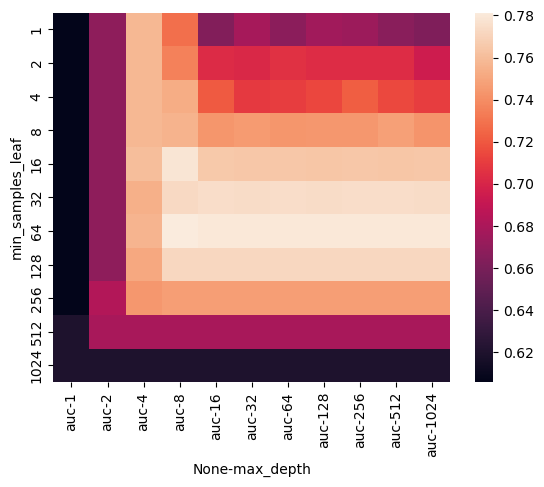

In [19]:
df_scores = pd.DataFrame(scores, columns=['max_depth', 'min_samples_leaf', 'auc'])
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', columns=['max_depth'], values=['auc'])
df_scores_pivot.round(3)

sns.heatmap(df_scores_pivot, annot=False, fmt=".3f")

In [33]:
np.unravel_index(np.argmax(df_scores_pivot.values[1:,1:]), df_scores_pivot.values[1:,1:].shape)

(np.int64(5), np.int64(2))

In [35]:
df_scores_pivot.values[6,3]

np.float64(0.7813597394105252)

In [38]:
clf = DecisionTreeClassifier(max_depth=8, min_samples_leaf=64)
clf.fit(X_train, y_train)

y_pred = clf.predict_proba(X_val)[:,1]
print("AUC:", roc_auc_score(y_val, y_pred))

AUC: 0.7813597394105252


Now, let's move to Random Forests.

In [8]:
params = {
    "n_estimators": 10,
    #"max_features":1/3,
    #"max_depth": 4,
    #"min_samples_split": 5,
    #"warm_start":True,
    #"oob_score":True,
    "random_state": 1,
}

rfc = RandomForestClassifier(**params)
rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=1)

In [9]:
roc_auc_score(y_val, rfc.predict_proba(X_val)[:,1])

np.float64(0.7867392409968275)

Again, we do some parameter tunning.

In [17]:
scores = []
depths = [7,10,12,15]
for n in range(1, 101, 5):
  for d in depths:
    rfc = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=1)
    rfc.fit(X_train, y_train)

    y_pred = rfc.predict_proba(X_val)[:,1]
    score = roc_auc_score(y_val, y_pred)
    scores.append((n, d, score))

Text(0, 0.5, 'AUC')

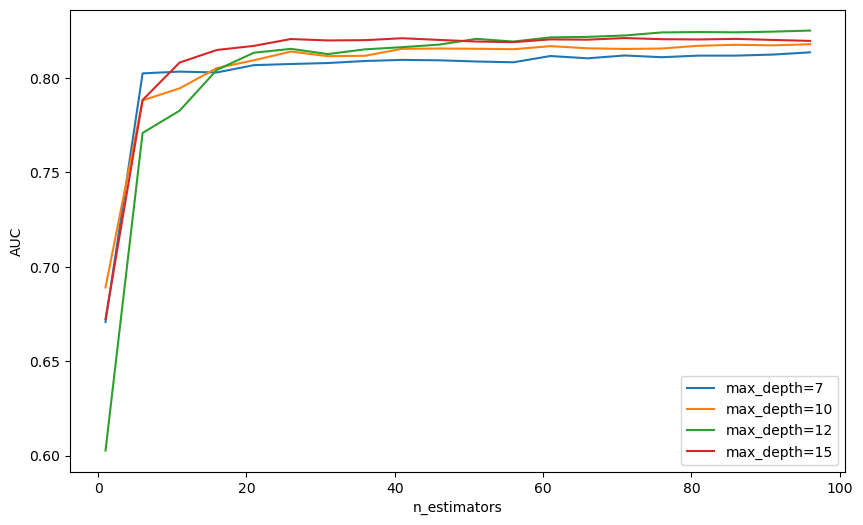

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

for d in depths:
    ax.plot([x[0] for x in scores if x[1]==d], [x[2] for x in scores if x[1]==d], label=f'max_depth={d}')
ax.legend()
ax.set_xlabel('n_estimators')
ax.set_ylabel('AUC')

We fix the maximum depth to the best scored, and optimize for the minimun samples to be at a leaf node.

In [20]:
scores = []
leaves = [3,5,10,50]
for n in range(1, 101, 5):
  for s in leaves:
    rfc = RandomForestClassifier(n_estimators=n, max_depth=12, min_samples_leaf=s, random_state=1)
    rfc.fit(X_train, y_train)

    y_pred = rfc.predict_proba(X_val)[:,1]
    score = roc_auc_score(y_val, y_pred)
    scores.append((n, s, score))

Text(0, 0.5, 'AUC')

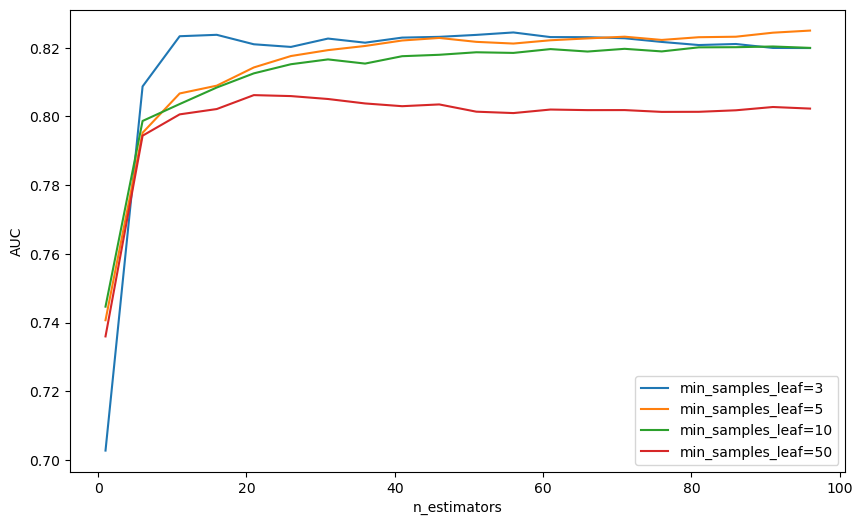

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

for s in leaves:
    ax.plot([x[0] for x in scores if x[1]==s], [x[2] for x in scores if x[1]==s], label=f'min_samples_leaf={s}')
ax.legend()
ax.set_xlabel('n_estimators')
ax.set_ylabel('AUC')

**Gradient boosting**: it also consists in training different decision trees, but in a sequantial way instead of in parallel. At the first iteration, the algorithm trains the model $F_0$ as a single decision tree (with max depth, min samples and other parameters set up). Then, a correction is added to the model in the direction of steepest descent of the gradient of a loss function:

$$
F_1(\vec{x}) = F_0(\vec{x}) + \underset{h_1 \in \mathcal{H}}{argmin}\left[ L(y_i,F_0(\vec{x}_i)+h_1(\vec{x}_i)) \right],
$$

where $\mathcal{H}$ is some space of base functions. In the case of decision trees, these functions are given by
$$
h_m(\vec{x})= \sum_j \gamma_{mj} R_{mj}(\vec{x}),
$$
with $R_{mj}(\vec{x})$ functions that return 1 if $\vec{x}$ is in the $j$-th region obtained by the decision tree, and 0 otherwise, and $\gamma_{mj}$ the predicted values for the model in the $m$-th iteration.

For better documentation, watch here https://gabrieltseng.github.io/posts/2018-02-25-XGB/

In [40]:
import xgboost as xgb
import io
from contextlib import redirect_stdout

In [9]:
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [10]:
xgb_params = {
    'eta': 0.3,# learning rate
    'max_depth': 6,# maximum depth of a tree
    'min_child_weight': 1,# minimum sum of instance weight needed in a child

    'objective': 'binary:logistic',
    'nthread': 2,

    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=10)

In [11]:
y_pred = model.predict(dval)
roc_auc_score(y_val, y_pred)

np.float64(0.8123017122375336)

Let's see how the algorithm improves results throughout iterations.

In [12]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

It is important to put "%%capture output" at the top of a cell, otherwise it will not work.

In [ ]:
%%capture output

xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 2,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

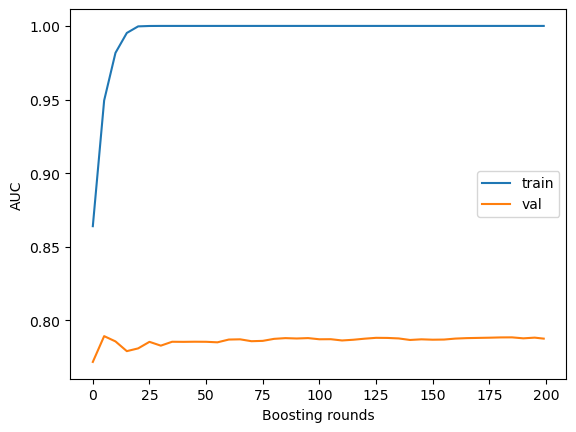

In [42]:
def parse_xgb_output(output):
    results = []

    #for line in output.stdout.strip().split('\n'):
    for line in output.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))

    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns=columns)
    return df_results

df_score = parse_xgb_output(output)

plt.plot(df_score.num_iter, df_score.train_auc, label='train')
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.xlabel('Boosting rounds')
plt.ylabel('AUC')
plt.legend()

Let's do some parameter tunning. The main parameters we should focus in are 'eta', 'max_depth', and 'min_child_weight'.

In [ ]:
eta_values = [1., 0.3, 0.1, 0.05, 0.01]
scores = np.zeros((len(df_score.num_iter), len(eta_values)))

for i, eta in enumerate(eta_values):
    xgb_params = {
        'eta': eta,
        'max_depth': 6,
        'min_child_weight': 1,

        'objective': 'binary:logistic',
        'eval_metric': 'auc',

        'nthread': 2,
        'seed': 1,
        'verbosity': 1,
    }

    with io.StringIO() as buffer:
        with redirect_stdout(buffer):
            model = xgb.train(
                xgb_params,
                dtrain,
                num_boost_round=200,
                verbose_eval=5,
                evals=watchlist
            )
        output = buffer.getvalue()

    df_score = parse_xgb_output(output)
    scores[:, i] = df_score.val_auc

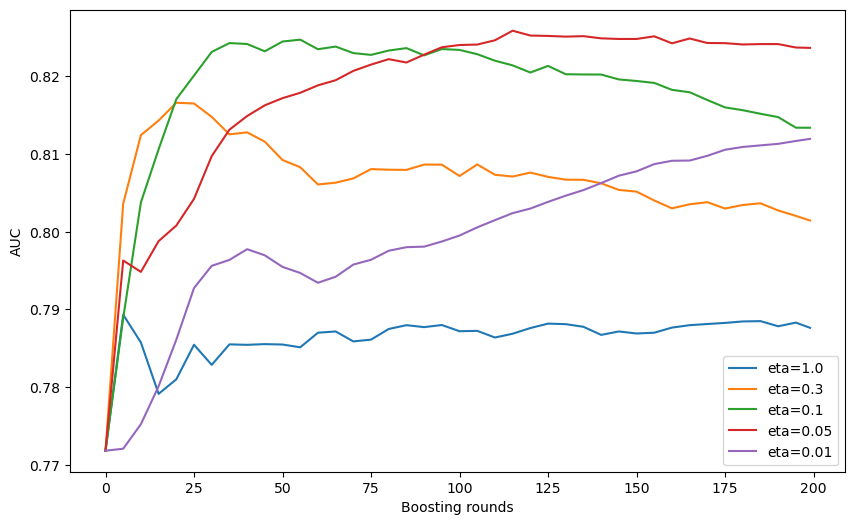

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

for i, eta in enumerate(eta_values):
    ax.plot(df_score.num_iter, scores[:, i], label=f'eta={eta}')

ax.set_xlabel('Boosting rounds')
ax.set_ylabel('AUC')
ax.legend()

In [49]:
maxdep_values = [3,4,6,8,10]
scores = np.zeros((len(df_score.num_iter), len(maxdep_values)))

for i, max_depth in enumerate(maxdep_values):
    xgb_params = {
        'eta': 0.1,
        'max_depth': max_depth,
        'min_child_weight': 1,

        'objective': 'binary:logistic',
        'eval_metric': 'auc',

        'nthread': 2,
        'seed': 1,
        'verbosity': 1,
    }

    with io.StringIO() as buffer:
        with redirect_stdout(buffer):
            model = xgb.train(
                xgb_params,
                dtrain,
                num_boost_round=200,
                verbose_eval=5,
                evals=watchlist
            )
        output = buffer.getvalue()

    df_score = parse_xgb_output(output)
    scores[:, i] = df_score.val_auc

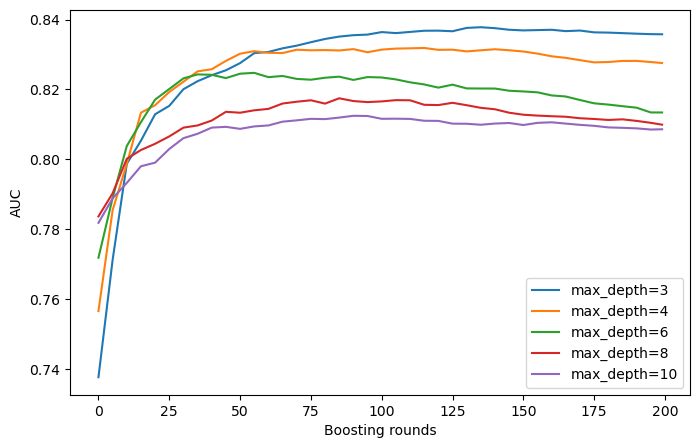

In [50]:
fig, ax = plt.subplots(figsize=(8, 5))

for i, max_depth in enumerate(maxdep_values):
    ax.plot(df_score.num_iter, scores[:, i], label=f'max_depth={max_depth}')

ax.set_xlabel('Boosting rounds')
ax.set_ylabel('AUC')
ax.legend()

In [51]:
min_child_weight_values = [1, 10, 30]
scores = np.zeros((len(df_score.num_iter), len(min_child_weight_values)))

for i, min_child_weight in enumerate(min_child_weight_values):
    xgb_params = {
        'eta': 0.1,
        'max_depth': 3,
        'min_child_weight': min_child_weight,

        'objective': 'binary:logistic',
        'eval_metric': 'auc',

        'nthread': 2,
        'seed': 1,
        'verbosity': 1,
    }

    with io.StringIO() as buffer:
        with redirect_stdout(buffer):
            model = xgb.train(
                xgb_params,
                dtrain,
                num_boost_round=200,
                verbose_eval=5,
                evals=watchlist
            )
        output = buffer.getvalue()

    df_score = parse_xgb_output(output)
    scores[:, i] = df_score.val_auc

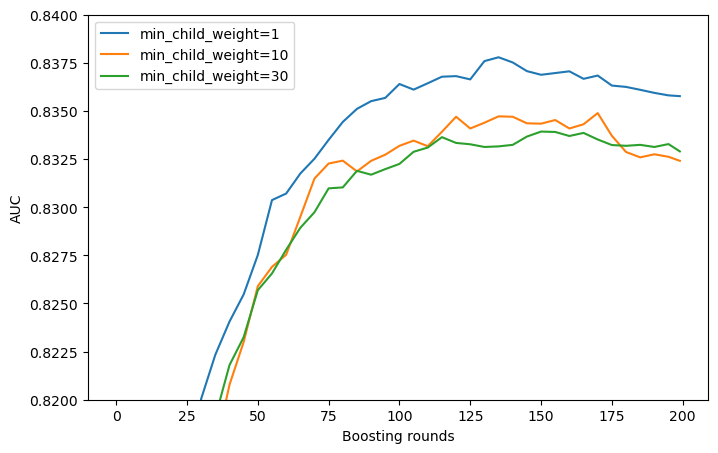

In [53]:
fig, ax = plt.subplots(figsize=(8, 5))

for i, min_child_weight in enumerate(min_child_weight_values):
    ax.plot(df_score.num_iter, scores[:, i], label=f'min_child_weight={min_child_weight}')

ax.set_xlabel('Boosting rounds')
ax.set_ylabel('AUC')

ax.set_ylim(0.82, 0.84)
ax.legend()

After tuning some parameters, we optimize using the values that performed best.

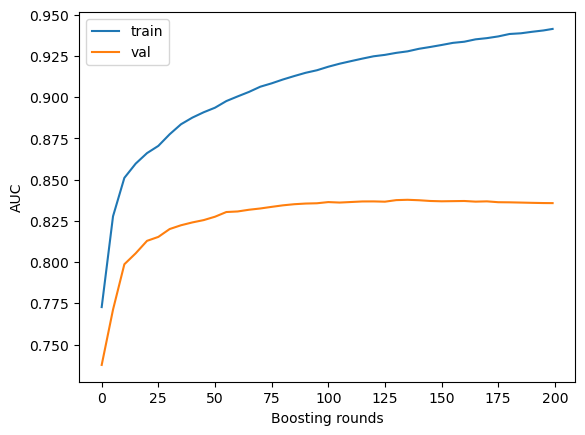

In [54]:
xgb_params = {
      'eta': 0.1,
      'max_depth': 3,
      'min_child_weight': 1,
      'objective': 'binary:logistic',
      'eval_metric': 'auc',
      'nthread': 2,
      'seed': 1,
      'verbosity': 1,
}

with io.StringIO() as buffer:
    with redirect_stdout(buffer):
        model = xgb.train(
            xgb_params,
            dtrain,
            num_boost_round=200,
            verbose_eval=5,
            evals=watchlist
        )
    output = buffer.getvalue()
df_score = parse_xgb_output(output)

plt.plot(df_score.num_iter, df_score.train_auc, label='train')
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.xlabel('Boosting rounds')
plt.ylabel('AUC')
plt.legend()